In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from google.colab import files

uploaded = files.upload()

Saving 16_air_quality_prediction.csv to 16_air_quality_prediction (1).csv


In [4]:
df = pd.read_csv("16_air_quality_prediction (1).csv")

print(df.head())

         date  location  pm2.5   pm10  temperature  predicted_aqi
0  2023-01-01  Istanbul  29.05  58.73         15.4          40.71
1  2023-01-01    Ankara  24.74  83.86         26.4          50.63
2  2023-01-01     Izmir  23.90  76.91         27.8          39.67
3  2023-01-01     Bursa  43.67  49.58         30.6          36.50
4  2023-01-02  Istanbul  28.40  76.31         23.9          46.89


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1460
Number of columns: 6


In [6]:
print(df.columns)

Index(['date', 'location', 'pm2.5', 'pm10', 'temperature', 'predicted_aqi'], dtype='object')


In [7]:
print(df.isnull().sum())

date             0
location         0
pm2.5            0
pm10             0
temperature      0
predicted_aqi    0
dtype: int64


In [8]:
df = df.dropna()

print("Rows after cleaning:", len(df))

Rows after cleaning: 1460


In [11]:
X = df[["pm2.5", "pm10"]]

y = df["predicted_aqi"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1168, 2)
Testing data: (292, 2)


In [13]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [14]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [15]:
y_pred = model.predict(X_test)

print("Predicted AQI values:")
print(y_pred[:10])

Predicted AQI values:
[44.0626 46.5268 50.6165 50.0217 30.6301 49.8803 40.8635 51.8183 39.8268
 31.2661]


In [16]:
result = pd.DataFrame({
    "Actual AQI": y_test.values,
    "Predicted AQI": y_pred
})

print(result.head(10))

   Actual AQI  Predicted AQI
0       36.09        44.0626
1       50.90        46.5268
2       45.56        50.6165
3       54.58        50.0217
4       38.84        30.6301
5       51.21        49.8803
6       43.72        40.8635
7       62.17        51.8183
8       33.42        39.8268
9       29.50        31.2661


In [17]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 4.8473352739726


In [18]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 6.179574255841487


In [19]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.5716649832132572


In [20]:
print("----- MODEL PERFORMANCE -----")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

----- MODEL PERFORMANCE -----
MAE  : 4.8473352739726
RMSE : 6.179574255841487
R²   : 0.5716649832132572


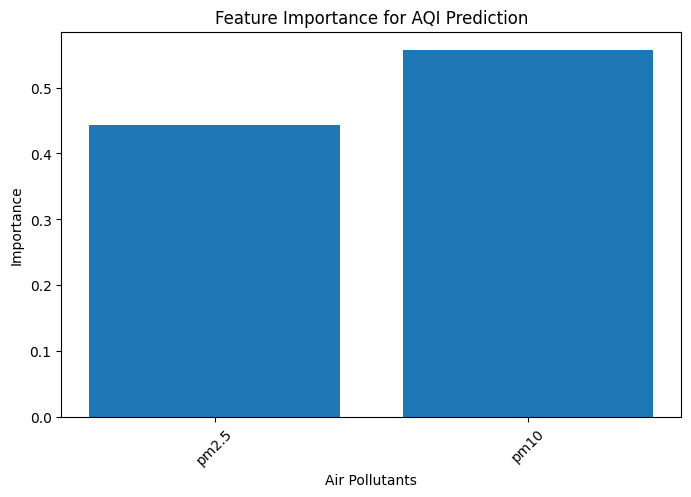

In [21]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.bar(features, importance)

plt.xlabel("Air Pollutants")
plt.ylabel("Importance")
plt.title("Feature Importance for AQI Prediction")

plt.xticks(rotation=45)

plt.show()

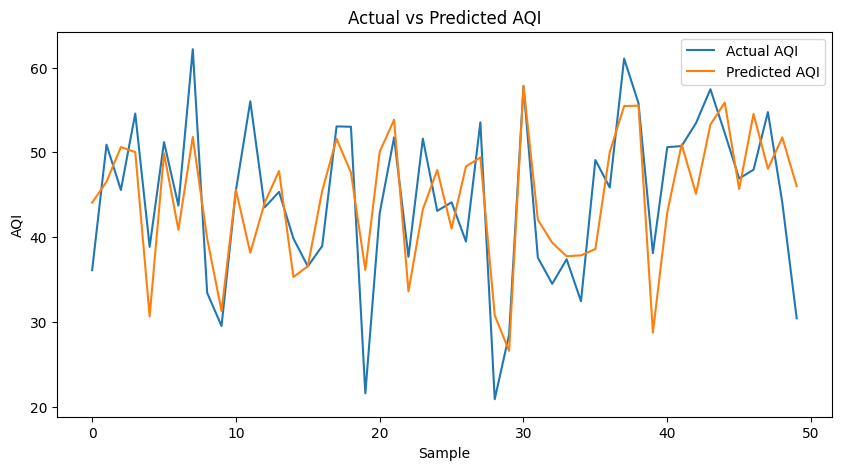

In [22]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label="Actual AQI")
plt.plot(y_pred[:50], label="Predicted AQI")

plt.xlabel("Sample")
plt.ylabel("AQI")
plt.title("Actual vs Predicted AQI")

plt.legend()

plt.show()

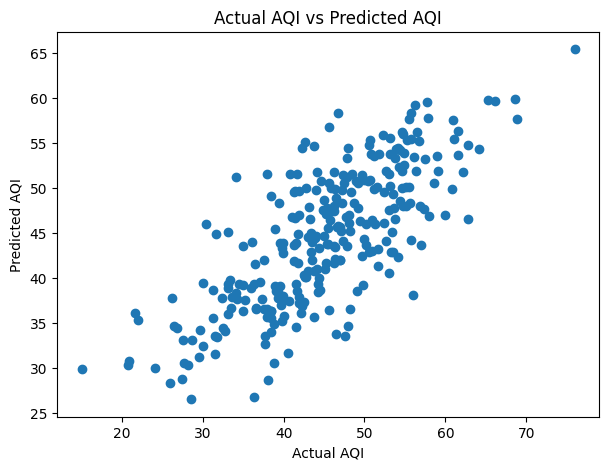

In [23]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.title("Actual AQI vs Predicted AQI")

plt.show()

In [25]:
new_data = pd.DataFrame({
    "pm2.5": [40],
    "pm10": [70]
})

predicted_aqi = model.predict(new_data)

print("Predicted AQI:", predicted_aqi[0])

Predicted AQI: 47.689799999999984


In [26]:
print("===================================")
print(" AIR QUALITY PREDICTION USING ML")
print("===================================")

print("Model Used : Random Forest Regression")
print("MAE        :", round(mae, 2))
print("RMSE       :", round(rmse, 2))
print("R² Score   :", round(r2, 2))
print("Predicted AQI :", round(predicted_aqi[0], 2))

 AIR QUALITY PREDICTION USING ML
Model Used : Random Forest Regression
MAE        : 4.85
RMSE       : 6.18
R² Score   : 0.57
Predicted AQI : 47.69
